In [103]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

In [104]:
df = pd.read_csv("/content/Bulgarian Telecom Customer Churn Dataset.csv")

# PART 1

**Step 1: Data Overview**

In [105]:
df.head()

,PID,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
0,123759242,Bronze,SOHO,6000.0,VM,2,NaN,NaN,2,40.17,0.0,40.17,NaN,No
1,126145737,Bronze,SOHO,6400.0,VM,3,NaN,NaN,3,40.17,0.0,40.17,13.39,No
2,123506355,Bronze,SOHO,6000.0,DI,2,3.0,NaN,5,40.17,0.0,40.17,20.09,No
3,112595585,Bronze,SOHO,4400.0,MT,1,2.0,NaN,3,40.17,0.0,40.17,40.17,No
4,115097935,Iron,SOHO,4000.0,AD,2,1.0,NaN,3,40.17,0.0,40.17,20.09,No


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8453 entries, 0 to 8452
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PID                     8453 non-null   object 
 1   CRM_PID_Value_Segment   8448 non-null   object 
 2   EffectiveSegment        8453 non-null   object 
 3   Billing_ZIP             8451 non-null   float64
 4   KA_name                 8453 non-null   object 
 5   Active_subscribers      8453 non-null   int64  
 6   Not_Active_subscribers  4304 non-null   float64
 7   Suspended_subscribers   352 non-null    float64
 8   Total_SUBs              8453 non-null   int64  
 9   AvgMobileRevenue        8453 non-null   float64
 10  AvgFIXRevenue           8453 non-null   float64
 11  TotalRevenue            8453 non-null   float64
 12  ARPU                    8452 non-null   float64
 13  CHURN                   8453 non-null   object 
dtypes: float64(7), int64(2), object(5)
memor

In [107]:
df.describe(include = 'all')

,PID,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
count,8453,8448,8453,8451.000000,8453,8453.000000,4304.000000,352.000000,8453.000000,8453.000000,8453.000000,8453.000000,8452.000000,8453
unique,8436,9,6,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,2.02E+12,Bronze,SOHO,NaN,VM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,5,3820,6301,NaN,769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7904
mean,NaN,NaN,NaN,4879.727725,NaN,7.774636,4.163336,1.576705,9.960132,148.011956,0.821185,148.833141,24.441789,NaN
std,NaN,NaN,NaN,1061.095394,NaN,6.680524,9.462847,1.979905,10.246648,102.570539,11.737880,103.250779,22.820585,NaN
min,NaN,NaN,NaN,1000.000000,NaN,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.670000,0.000000,NaN
25%,NaN,NaN,NaN,4003.000000,NaN,4.000000,1.000000,1.000000,5.000000,71.500000,0.000000,71.830000,14.070000,NaN
50%,NaN,NaN,NaN,4400.000000,NaN,6.000000,2.000000,1.000000,7.000000,113.170000,0.000000,113.670000,19.315000,NaN
75%,NaN,NaN,NaN,6000.000000,NaN,10.000000,4.000000,1.000000,12.000000,191.170000,0.000000,192.330000,27.255000,NaN


In [108]:
df.shape

(8453, 14)

**Step 2: Handling the Data**

In [109]:
df.duplicated().sum()

np.int64(0)

In [110]:
df.isnull().sum().sort_values(ascending=False)

,0
Suspended_subscribers,8101
Not_Active_subscribers,4149
CRM_PID_Value_Segment,5
Billing_ZIP,2
ARPU,1
PID,0
Active_subscribers,0
KA_name,0
EffectiveSegment,0
Total_SUBs,0


In [111]:
# Convert text NaNs to real NaNs
df.replace(['NaN', 'nan', ' ', ''], np.nan, inplace=True)

# Fill missing values
df.fillna({
    'Suspended_subscribers': df['Suspended_subscribers'].mean(),
    'Not_Active_subscribers': df['Not_Active_subscribers'].mean(),
    'CRM_PID_Value_Segment': df['CRM_PID_Value_Segment'].mode()[0],
    'Billing_ZIP': df['Billing_ZIP'].mean(),
    'ARPU': df['ARPU'].mean()
}, inplace=True)

# Final check
if df.isnull().sum().sum() == 0:
    print("Dataset is 100% clean — no missing (NaN) values remain.")

Dataset is 100% clean — no missing (NaN) values remain.


In [112]:
df.isnull().sum()

,0
PID,0
CRM_PID_Value_Segment,0
EffectiveSegment,0
Billing_ZIP,0
KA_name,0
Active_subscribers,0
Not_Active_subscribers,0
Suspended_subscribers,0
Total_SUBs,0
AvgMobileRevenue,0


In [113]:
df.dtypes

,0
PID,object
CRM_PID_Value_Segment,object
EffectiveSegment,object
Billing_ZIP,float64
KA_name,object
Active_subscribers,int64
Not_Active_subscribers,float64
Suspended_subscribers,float64
Total_SUBs,int64
AvgMobileRevenue,float64


In [114]:
# Converting the PID variable from object to float, as it has numeric data.
df['PID'] = pd.to_numeric(df['PID'], errors='coerce')

# Check the data types after conversion
print("Data types after converting PID:")
print(df.dtypes)

Data types after converting PID:
PID                       float64
CRM_PID_Value_Segment      object
EffectiveSegment           object
Billing_ZIP               float64
KA_name                    object
Active_subscribers          int64
Not_Active_subscribers    float64
Suspended_subscribers     float64
Total_SUBs                  int64
AvgMobileRevenue          float64
AvgFIXRevenue             float64
TotalRevenue              float64
ARPU                      float64
CHURN                      object
dtype: object


In [115]:
# Remove extra space in column name
df.rename(columns={'AvgMobileRevenue ': 'AvgMobileRevenue'}, inplace=True)

**Step 3: Feature Engineering**

*Feature 1: Activity Ratio*

* Measures how active the customers are compared to their total subscribers.

*Feature 2: Mobile Revenue Share*

* Shows how much of total revenue comes from mobile services.

*Feature 3: Revenue per Subscriber*

* Indicates average earning per individual subscription.

In [116]:
df['Activity_Ratio'] = df['Active_subscribers'] / df['Total_SUBs']
df['Mobile_Revenue_Share'] = df['AvgMobileRevenue'] / df['TotalRevenue']
df['Revenue_per_Subscriber'] = df['TotalRevenue'] / df['Total_SUBs']

In [117]:
# Confirm new features and data quality
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8453 entries, 0 to 8452
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PID                     8364 non-null   float64
 1   CRM_PID_Value_Segment   8453 non-null   object 
 2   EffectiveSegment        8453 non-null   object 
 3   Billing_ZIP             8453 non-null   float64
 4   KA_name                 8453 non-null   object 
 5   Active_subscribers      8453 non-null   int64  
 6   Not_Active_subscribers  8453 non-null   float64
 7   Suspended_subscribers   8453 non-null   float64
 8   Total_SUBs              8453 non-null   int64  
 9   AvgMobileRevenue        8453 non-null   float64
 10  AvgFIXRevenue           8453 non-null   float64
 11  TotalRevenue            8453 non-null   float64
 12  ARPU                    8453 non-null   float64
 13  CHURN                   8453 non-null   object 
 14  Activity_Ratio          8453 non-null   

,PID,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN,Activity_Ratio,Mobile_Revenue_Share,Revenue_per_Subscriber
0,123759242.0,Bronze,SOHO,6000.0,VM,2,4.163336,1.576705,2,40.17,0.0,40.17,24.441789,No,1.000000,1.0,20.085
1,126145737.0,Bronze,SOHO,6400.0,VM,3,4.163336,1.576705,3,40.17,0.0,40.17,13.390000,No,1.000000,1.0,13.390
2,123506355.0,Bronze,SOHO,6000.0,DI,2,3.000000,1.576705,5,40.17,0.0,40.17,20.090000,No,0.400000,1.0,8.034
3,112595585.0,Bronze,SOHO,4400.0,MT,1,2.000000,1.576705,3,40.17,0.0,40.17,40.170000,No,0.333333,1.0,13.390
4,115097935.0,Iron,SOHO,4000.0,AD,2,1.000000,1.576705,3,40.17,0.0,40.17,20.090000,No,0.666667,1.0,13.390


**Step 4: Outlier Detection and Removal**

In [118]:
# Select numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
catagorical_cols =df.select_dtypes(include=['object']).columns.tolist()

In [119]:
# Identify outliers using IQR
print("\nIdentifying outliers using IQR:")
outlier_indices = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outlier_indices[col] = outliers
    print(f"  {col:>20}: {len(outliers)} outliers identified")

# Combine indices from all columns
all_outlier_indices = [idx for indices in outlier_indices.values() for idx in indices]
all_outlier_indices = list(set(all_outlier_indices)) # Remove duplicates

print(f"\nTotal unique outliers identified across numeric columns: {len(all_outlier_indices)}")


Identifying outliers using IQR:
                   PID: 902 outliers identified
           Billing_ZIP: 13 outliers identified
    Active_subscribers: 483 outliers identified
  Not_Active_subscribers: 471 outliers identified
  Suspended_subscribers: 352 outliers identified
            Total_SUBs: 606 outliers identified
      AvgMobileRevenue: 466 outliers identified
         AvgFIXRevenue: 122 outliers identified
          TotalRevenue: 465 outliers identified
                  ARPU: 577 outliers identified
        Activity_Ratio: 378 outliers identified
  Mobile_Revenue_Share: 122 outliers identified
  Revenue_per_Subscriber: 493 outliers identified

Total unique outliers identified across numeric columns: 2762


**NOTE 1**

From the above list of outliers;

The columns PID and Billing_ZIP were excluded from the outlier treatment process because they do not represent measurable business or behavioral variables.

* PID is a unique identifier assigned to each customer. It has no numerical meaning, so large or small values are not true outliers — they’re just random ID numbers.

* Billing_ZIP represents geographical codes, and variations in ZIP values simply indicate different locations, not anomalies.
Therefore, applying outlier detection or capping on these columns would be meaningless and could distort valid information.

**NOTE 2**

We are capping (Winsorizing) the outliers instead of removing them because, in this telecom churn dataset, the extreme values likely represent real high-value customers or large corporate accounts rather than data errors. Removing these records would lead to a loss of valuable business information and distort the true customer behavior pattern. By capping values at the 1st and 99th percentiles, we reduce the influence of extreme points while still preserving all meaningful data. This approach ensures the dataset remains realistic, balanced, and reliable for building accurate machine learning models without compromising important business insights.

In [120]:
# Convert to numeric where needed
num_cols = ['Active_subscribers', 'Not_Active_subscribers', 'Suspended_subscribers',
            'Total_SUBs', 'AvgMobileRevenue', 'AvgFIXRevenue', 'TotalRevenue', 'ARPU']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Make a true copy BEFORE capping
df_before_outliers = df.copy()

In [121]:
# Apply IQR capping for each numeric column
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [122]:
def count_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((data[col] < lower) | (data[col] > upper)).sum()

for col in num_cols:
    before = count_outliers(df_before_outliers, col)
    after = count_outliers(df, col)
    print(f"{col}: {before} → {after} (outliers reduced)")

Active_subscribers: 483 → 0 (outliers reduced)
Not_Active_subscribers: 471 → 0 (outliers reduced)
Suspended_subscribers: 352 → 0 (outliers reduced)
Total_SUBs: 606 → 0 (outliers reduced)
AvgMobileRevenue: 466 → 0 (outliers reduced)
AvgFIXRevenue: 122 → 0 (outliers reduced)
TotalRevenue: 465 → 0 (outliers reduced)
ARPU: 577 → 0 (outliers reduced)


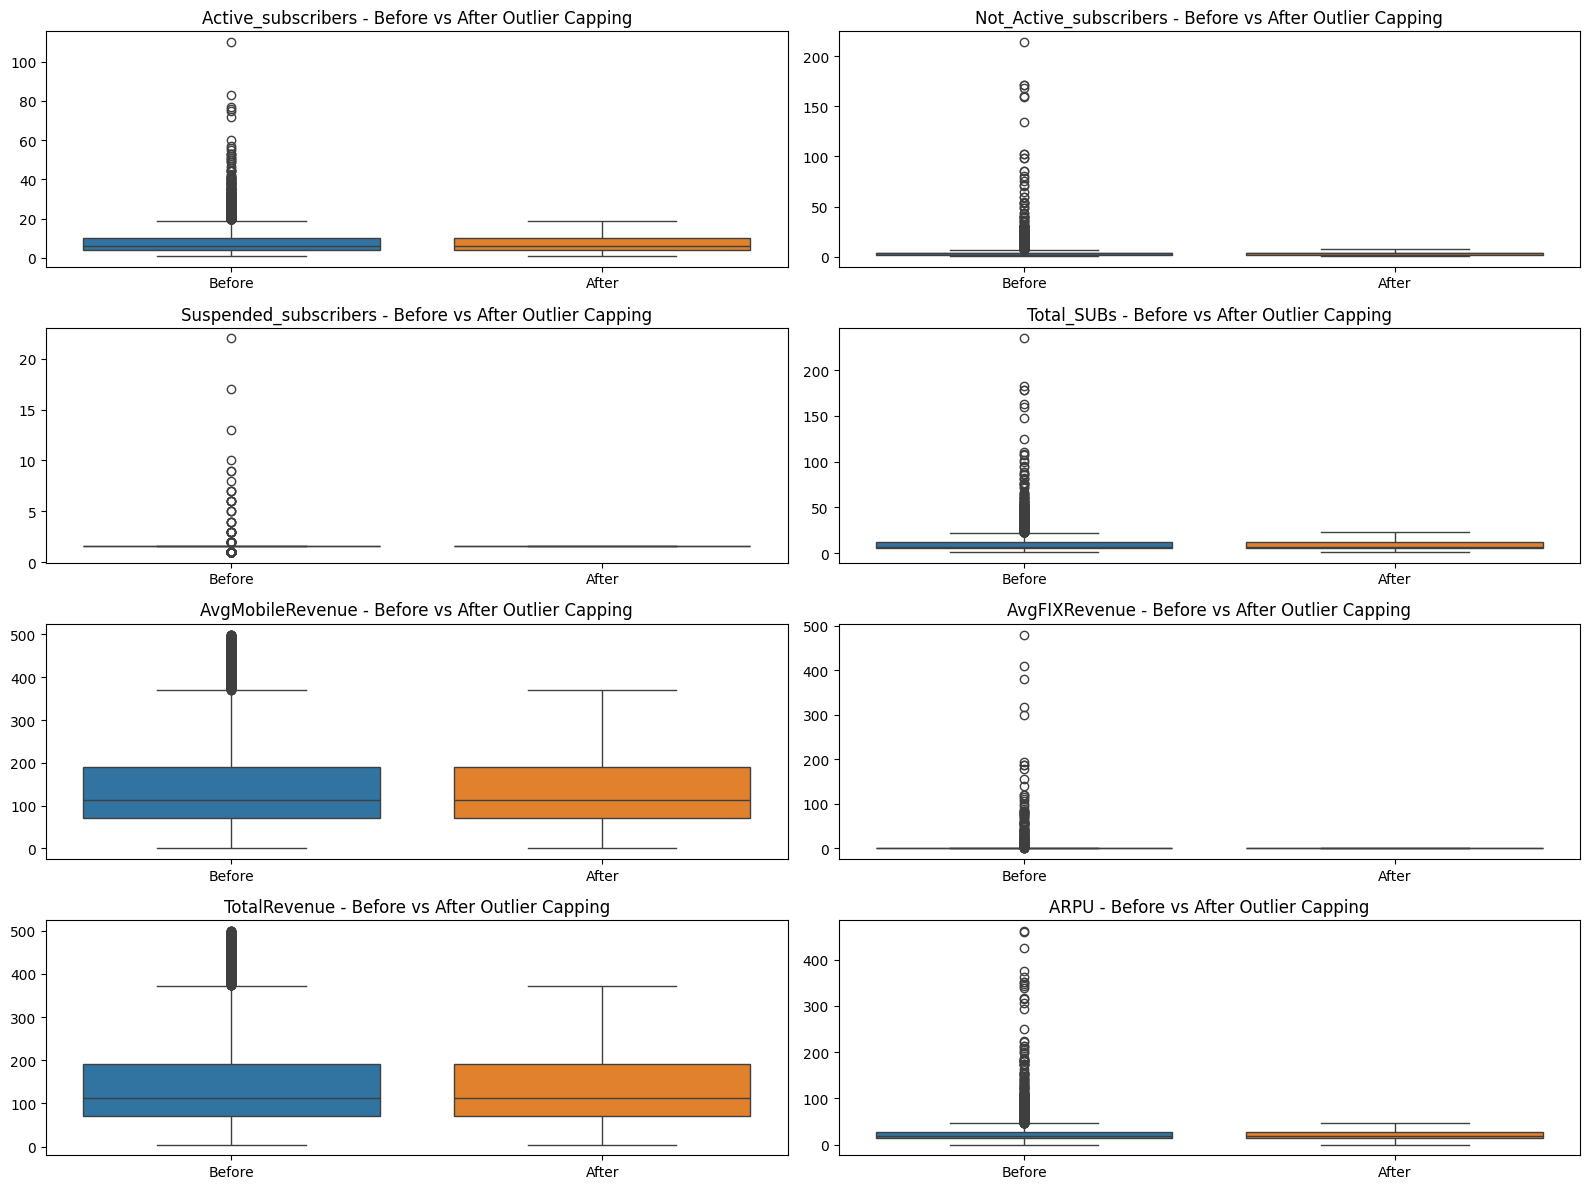

In [123]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(data=pd.DataFrame({'Before': df_before_outliers[col], 'After': df[col]}))
    plt.title(f"{col} - Before vs After Outlier Capping")
    plt.xlabel('')
plt.tight_layout()
plt.show()

**Step 5: Target Variable Mapping and Encode Target Variable**

In [124]:
# Convert CHURN to numeric (0 = No, 1 = Yes)
df['CHURN'] = df['CHURN'].map({'No': 0, 'Yes': 1})

Churn value counts:
CHURN
0    7904
1     549
Name: count, dtype: int64

Churn class distribution (%):
CHURN
0    93.505264
1     6.494736
Name: proportion, dtype: float64


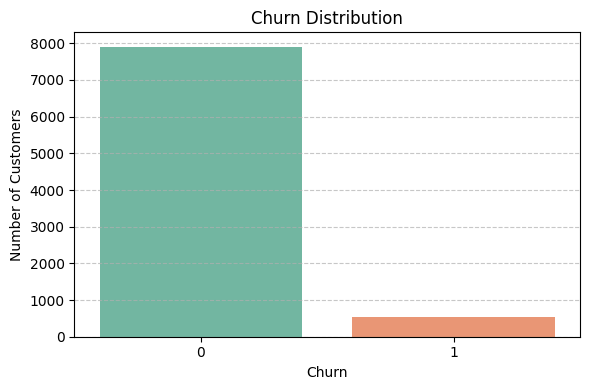

In [125]:
# Check value counts
print("Churn value counts:")
print(df['CHURN'].value_counts())

# Check proportions
print("\nChurn class distribution (%):")
print(df['CHURN'].value_counts(normalize=True) * 100)

# Visualize with a count plot
plt.figure(figsize=(6, 4))
sns.countplot(x='CHURN', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# PART 2

**Exploratory Data Analysis**

In [126]:
# Summary Statistics for numerical columns
numeric_columns = df.select_dtypes(include=[np.number])
summary_stats = numeric_columns.describe()
print("\nSummary Statistics:")
print(summary_stats)


Summary Statistics:
                PID  Billing_ZIP  Active_subscribers  Not_Active_subscribers  \
count  8.364000e+03  8453.000000         8453.000000             8453.000000   
mean   7.071315e+09  4879.727725            7.290903                3.509051   
std    1.746893e+11  1060.969843            4.923620                1.695662   
min    2.202560e+05  1000.000000            1.000000                1.000000   
25%    1.155368e+08  4003.000000            4.000000                2.000000   
50%    1.236344e+08  4400.000000            6.000000                4.163336   
75%    2.002313e+08  6000.000000           10.000000                4.163336   
max    8.320000e+12  9644.000000           19.000000                7.408341   

       Suspended_subscribers   Total_SUBs  AvgMobileRevenue  AvgFIXRevenue  \
count           8.453000e+03  8453.000000       8453.000000         8453.0   
mean            1.576705e+00     8.996688        145.052470            0.0   
std             7.483346

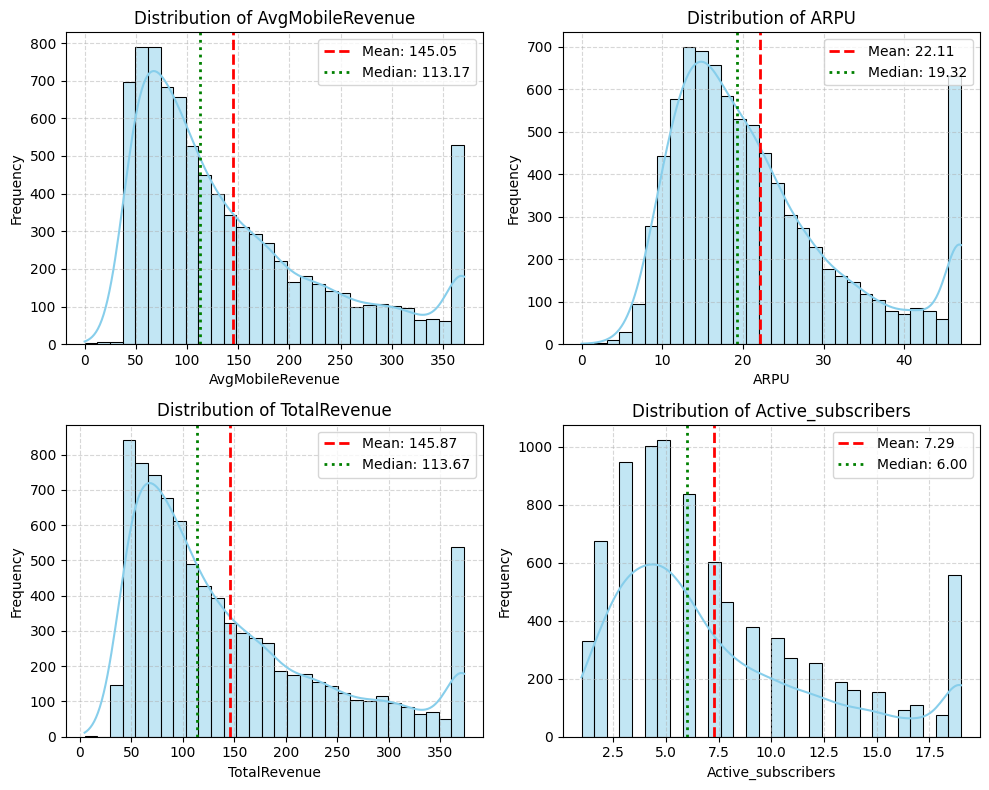

In [127]:
# List of numeric columns to visualize
numeric_cols = ['AvgMobileRevenue', 'ARPU', 'TotalRevenue', 'Active_subscribers']

# Set up the figure layout
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Loop through each column and plot histogram with vlines
for i, col in enumerate(numeric_cols):
    ax = axes[i // 2, i % 2]
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='skyblue', edgecolor='black')

# Calculate mean and median
    mean_val = df[col].mean()
    median_val = df[col].median()

# Add vertical lines
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle=':', linewidth=2, label=f'Median: {median_val:.2f}')

# Set titles and labels
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

# Final layout adjustment
plt.tight_layout()
plt.show()

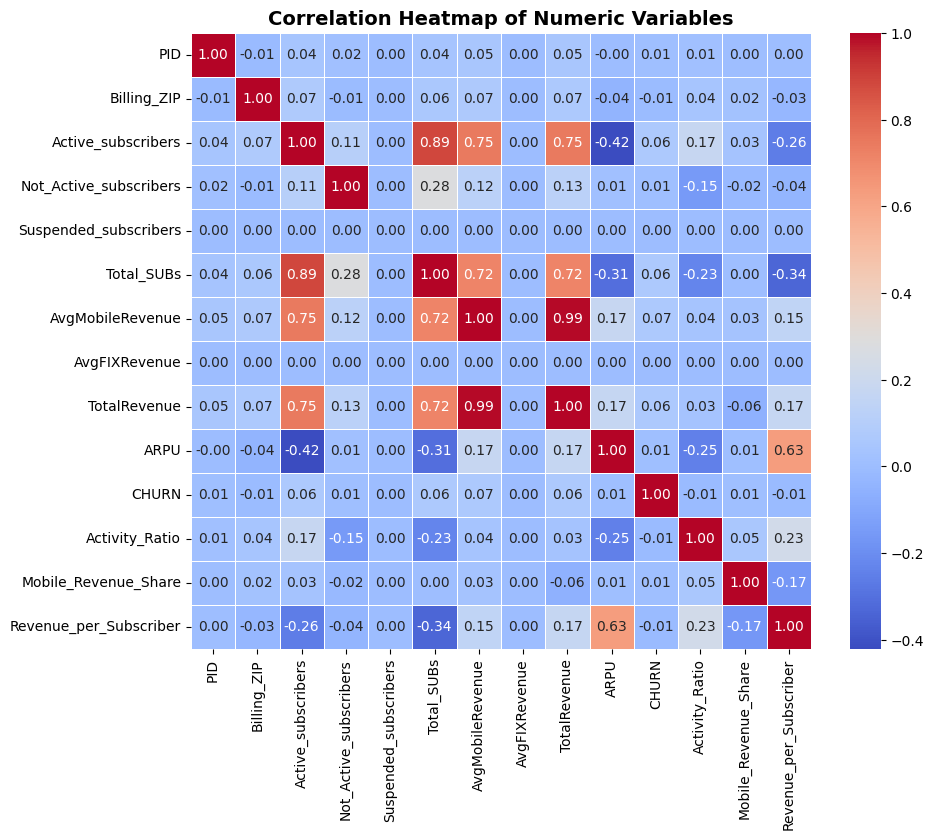

In [128]:
# Compute correlation matrix again
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Replace NaN correlations (caused by constant/zero columns) with 0 for visualization
corr_matrix_filled = corr_matrix.fillna(0)

# Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix_filled, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14, fontweight='bold')
plt.show()

AvgFIXRevenue and Suspended_subscribers variables are highly imbalanced.
So, even after Handling data and Outliers performance, probably they don’t change much—they are constant or almost constant.
Correlation measures how two variables move together. If a variable doesn’t change, its standard deviation is 0.
and because they are highly imbalance as NaN - NaN appears as 0.00
it means: these columns have no meaningful correlation with others (because they are constant).
this is correct for visualization, but as interpretation - that correlation is not meaningful for these constant columns.

# PART 3

**Step 1: Define Features and Target Variable**

In [129]:
# Define independent (X) and dependent (y) variables
X = df.drop(['PID', 'CHURN'], axis=1)
y = df['CHURN']

**Step 2: Encode Categorical Variables**

Categorical variables such as CRM_PID_Value_Segment, EffectiveSegment, and KA_name are transformed using one-hot encoding so that machine learning algorithms can process them.

In [130]:
# Perform One-Hot Encoding for categorical features
X = pd.get_dummies(X, columns=['CRM_PID_Value_Segment',
                               'EffectiveSegment',
                               'KA_name'], drop_first=True)

**Step 3: Split the Data**

The dataset is divided into training and testing sets (80%–20%) to evaluate how well models generalize to unseen data.

In [131]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Step 4: Scale Numerical Variables**

Numerical features are standardized to ensure that all values contribute equally to model performance, especially for algorithms sensitive to scale.

In [132]:
# Apply StandardScaler to numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [133]:
# save Preprocessing
import joblib
joblib.dump(scaler, 'scaler.pkl')

# save the final feature column list after encoding
trained_feature_columns = X.columns.tolist()
joblib.dump(trained_feature_columns, 'trained_feature_columns.pkl')

print("Preprocessing and feature columns saved successfully.")

Preprocessing and feature columns saved successfully.


**Step 5: Machine Learning Model**

* Logistic Regression
* Random Forest
* XGBoost
* LightGBM
* Support Vector Machine (SVM)

In [134]:
import warnings
warnings.filterwarnings("ignore")  # Suppress unnecessary warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Handle imbalance with class_weight='balanced' (for models that support it)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=10, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
}

**Step 6: Evaluation Function**

In [135]:
def evaluate_model(y_true, y_pred):
    """Evaluate and display model performance using key metrics."""
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 3))
    print("Recall:", round(recall_score(y_true, y_pred, zero_division=0), 3))
    print("F1 Score:", round(f1_score(y_true, y_pred, zero_division=0), 3))
    print("ROC-AUC:", round(roc_auc_score(y_true, y_pred), 3))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

**Step 7: Train and Evaluate All Models**

In [136]:
results = {}

for name, model in models.items():
    print(f"\n==============================")
    print(f"Model: {name}")
    print(f"==============================")

    # Train the model
    model.fit(X_train, y_train)

    # If LightGBM, save the model
    if name == "LightGBM":
        joblib.dump(model, 'lightgbm_model.pkl')
        print("LightGBM model saved as lightgbm_model.pkl")

    # Predict on test data
    y_pred = model.predict(X_test)

    # Store metrics
    results[name] = {
        'Accuracy': round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 3),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 3),
        'F1 Score': round(f1_score(y_test, y_pred, zero_division=0), 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_pred), 3)
    }

    # Print key metrics
    evaluate_model(y_test, y_pred)

# Convert to DataFrame for comparison
results_df = pd.DataFrame(results).T
print("\n===== Overall Model Performance Comparison =====")
display(results_df)


Model: Logistic Regression
Accuracy: 0.577
Precision: 0.078
Recall: 0.509
F1 Score: 0.135
ROC-AUC: 0.545

Confusion Matrix:
 [[919 662]
 [ 54  56]]

Model: Random Forest
Accuracy: 0.933
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.499

Confusion Matrix:
 [[1578    3]
 [ 110    0]]

Model: XGBoost
Accuracy: 0.888
Precision: 0.065
Recall: 0.055
F1 Score: 0.059
ROC-AUC: 0.5

Confusion Matrix:
 [[1495   86]
 [ 104    6]]

Model: LightGBM
[LightGBM] [Info] Number of positive: 439, number of negative: 6323
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1525
[LightGBM] [Info] Number of data points in the train set: 6762, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Li

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.577,0.078,0.509,0.135,0.545
Random Forest,0.933,0.000,0.000,0.000,0.499
XGBoost,0.888,0.065,0.055,0.059,0.500
LightGBM,0.826,0.113,0.245,0.155,0.556
SVM,0.672,0.075,0.355,0.123,0.525


In [137]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: CHURN
0    6323
1     439
Name: count, dtype: int64
After SMOTE: CHURN
0    6323
1    6323
Name: count, dtype: int64


SMOTE successfully generated synthetic minority samples to balance the dataset.
This step ensures your models learn to recognize churners, not just predict “no churn” all the time.

# Part 4



**Step 1: Train and Evaluate on Balanced Data**

In [138]:
results_smote = {}

for name, model in models.items():
    print(f"\n==============================")
    print(f"Model: {name}")
    print(f"==============================")

    # Train on balanced data (SMOTE)
    model.fit(X_train_res, y_train_res)

    # Predict on original test set
    y_pred = model.predict(X_test)

    # Store metrics (converted to %)
    results_smote[name] = {
        'Accuracy (%)':   round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision (%)':  round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
        'Recall (%)':     round(recall_score(y_test, y_pred, zero_division=0) * 100, 2),
        'F1 Score (%)':   round(f1_score(y_test, y_pred, zero_division=0) * 100, 2),
        'ROC-AUC (%)':    round(roc_auc_score(y_test, y_pred) * 100, 2)
    }

    # Print metrics
    print("Accuracy (%):",  round(accuracy_score(y_test, y_pred) * 100, 2))
    print("Precision (%):", round(precision_score(y_test, y_pred, zero_division=0) * 100, 2))
    print("Recall (%):",    round(recall_score(y_test, y_pred, zero_division=0) * 100, 2))
    print("F1 Score (%):",  round(f1_score(y_test, y_pred, zero_division=0) * 100, 2))
    print("ROC-AUC (%):",   round(roc_auc_score(y_test, y_pred) * 100, 2))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Convert to DataFrame for easy comparison
results_smote_df = pd.DataFrame(results_smote).T
print("\n===== Model Performance After SMOTE (%) =====")
display(results_smote_df)


Model: Logistic Regression
Accuracy (%): 55.29
Precision (%): 7.05
Recall (%): 48.18
F1 Score (%): 12.3
ROC-AUC (%): 51.98

Confusion Matrix:
 [[882 699]
 [ 57  53]]

Model: Random Forest
Accuracy (%): 90.83
Precision (%): 4.08
Recall (%): 1.82
F1 Score (%): 2.52
ROC-AUC (%): 49.42

Confusion Matrix:
 [[1534   47]
 [ 108    2]]

Model: XGBoost
Accuracy (%): 80.19
Precision (%): 7.55
Recall (%): 18.18
F1 Score (%): 10.67
ROC-AUC (%): 51.34

Confusion Matrix:
 [[1336  245]
 [  90   20]]

Model: LightGBM
[LightGBM] [Info] Number of positive: 6323, number of negative: 6323
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003759 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3413
[LightGBM] [Info] Number of data points in the train set: 12646, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=

,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
Logistic Regression,55.29,7.05,48.18,12.30,51.98
Random Forest,90.83,4.08,1.82,2.52,49.42
XGBoost,80.19,7.55,18.18,10.67,51.34
LightGBM,92.61,14.29,2.73,4.58,50.79
SVM,70.08,8.23,35.45,13.36,53.97


**Step 2: Visual Comparison**

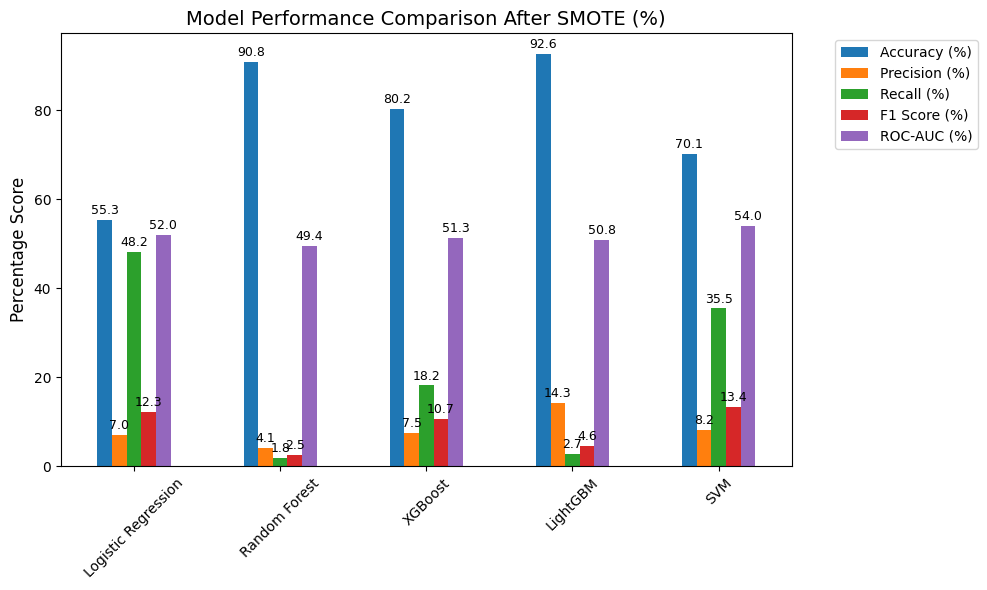

In [139]:
# Bar chart to visualize results
ax = results_smote_df.plot(kind='bar', figsize=(10, 6))

# Add chart details
plt.title("Model Performance Comparison After SMOTE (%)", fontsize=14)
plt.ylabel("Percentage Score", fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='edge', fontsize=9, padding=2)

plt.tight_layout()
plt.show()

Saved to: fig3.42metric_profiles.png


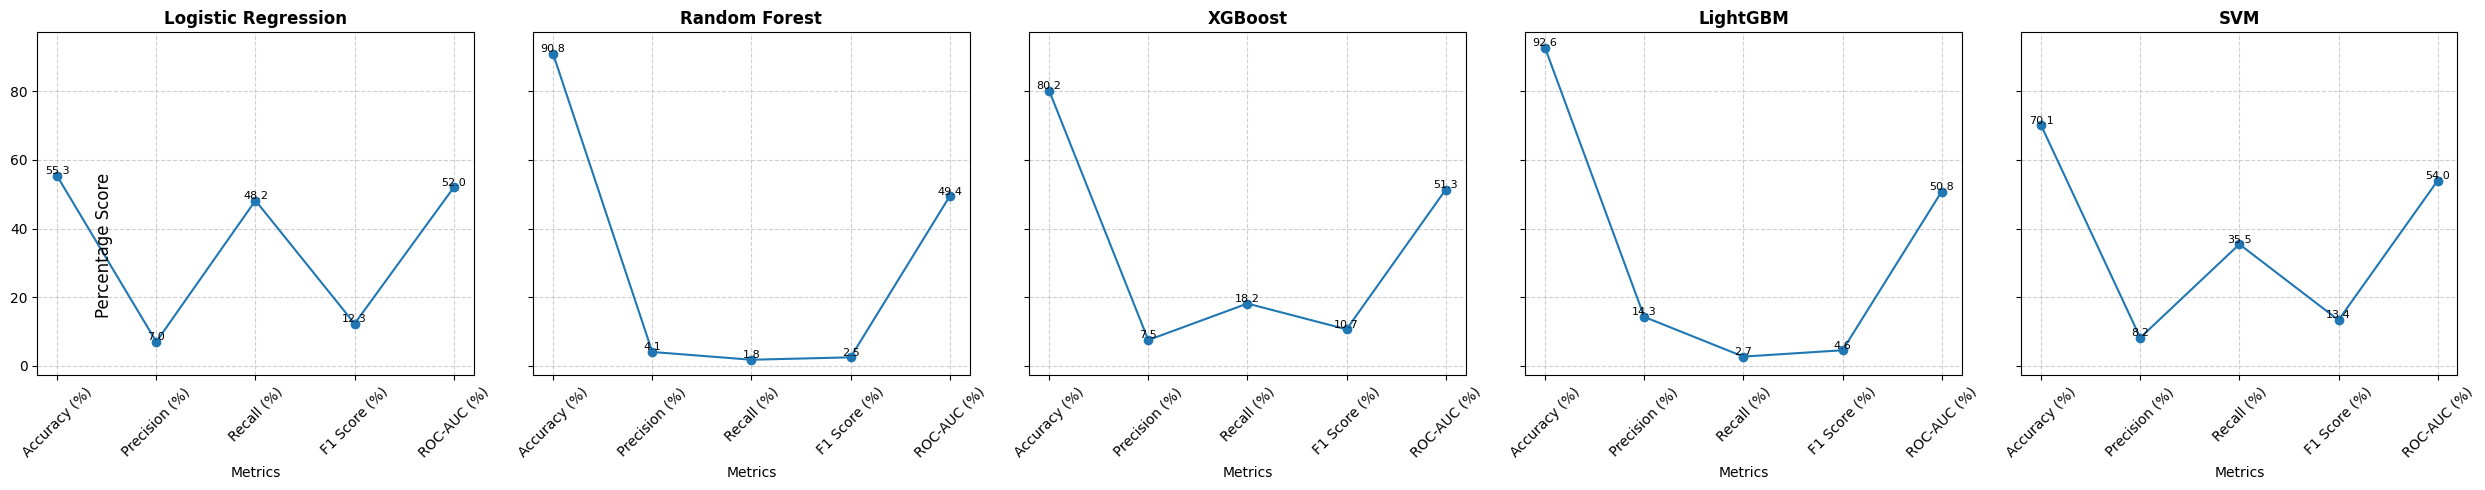

In [140]:
# Number of models
num_models = len(results_smote_df.index)

# Create horizontal subplots
fig, axes = plt.subplots(1, num_models, figsize=(5 * num_models, 5), sharey=True)

# Loop through each model and plot in its subplot
for i, model_name in enumerate(results_smote_df.index):
    ax = axes[i]
    metrics = results_smote_df.columns
    values = results_smote_df.loc[model_name]

    # Plot line chart with consistent color
    ax.plot(metrics, values, marker='o', linestyle='-', color='tab:blue')

    # Annotate each point
    for j, value in enumerate(values):
        ax.text(j, value + 0.5, f'{value:.1f}', ha='center', fontsize=8)

    # Chart details
    ax.set_title(f"{model_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Metrics", fontsize=10)
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, rotation=45)
    ax.grid(True, linestyle='--', alpha=0.6)

# Shared Y-axis label
fig.text(0.04, 0.5, 'Percentage Score', va='center', rotation='vertical', fontsize=12)
plt.tight_layout()
out = "fig3.42metric_profiles.png"   # or .pdf/.svg
plt.savefig(out, dpi=300, bbox_inches="tight")
print("Saved to:", out)
plt.show()


**Step 3: Feature Importance (for Best Model)**

**Best Model = LightGBM**

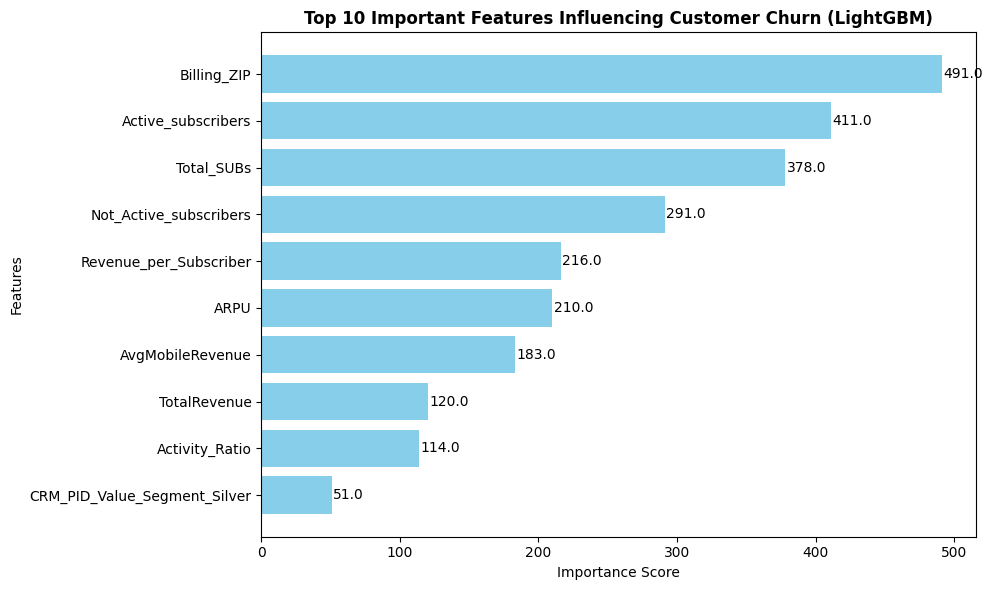

In [141]:
# Step 3: Enhanced Feature Importance Visualization (LightGBM)
best_model = models["LightGBM"]

importances = best_model.feature_importances_
feature_names = X.columns  # original feature names

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# Plot horizontal bar chart with values
plt.figure(figsize=(10,6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                color='skyblue')
plt.gca().invert_yaxis()  # highest importance at the top

# Add text labels (importance values)
for bar in bars:
    plt.text(
        bar.get_width() + 1,               # position slightly right of bar
        bar.get_y() + bar.get_height()/2,  # vertically center text
        f'{bar.get_width():.1f}',          # show one decimal
        va='center'
    )

plt.title("Top 10 Important Features Influencing Customer Churn (LightGBM)",
          fontsize=12, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

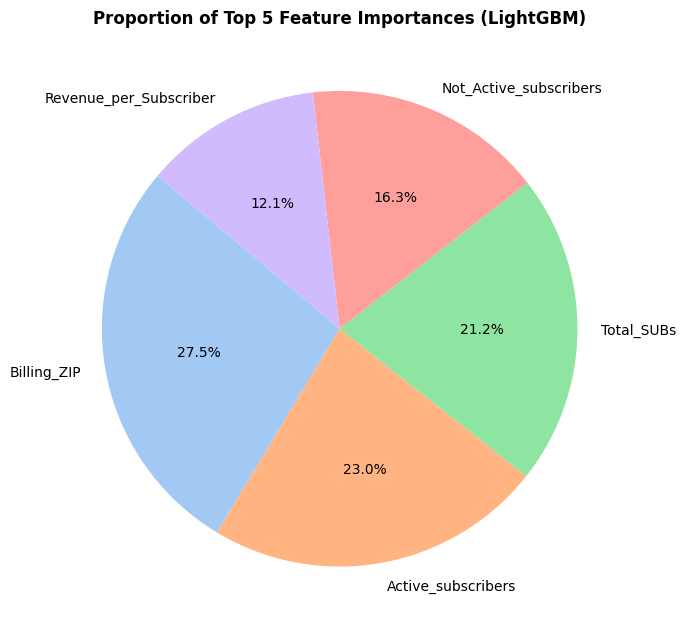

In [142]:
# Extra Visualization: Pie Chart of Top 5 Features
top5 = importance_df.head(5)

plt.figure(figsize=(7,7))
plt.pie(
    top5['Importance'],
    labels=top5['Feature'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')
)
plt.title("Proportion of Top 5 Feature Importances (LightGBM)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [143]:
# Step 1: Save cleaned DataFrame to CSV
df.to_csv('cleaned_churn_dataset.csv', index=False)

In [144]:
import gradio as gr
import joblib
import numpy as np

In [145]:
try:
    model = joblib.load('lightgbm_model.pkl')
    scaler = joblib.load('scaler.pkl')
    feature_cols = joblib.load('trained_feature_columns.pkl')
    df = pd.read_csv('cleaned_churn_dataset.csv')
except FileNotFoundError:
    print("Error: Model/Scaler/Column/CSV files not found.")
    print("Please make sure all 4 files are in the same directory as app.py")
    exit()
DEFAULT_BILLING_ZIP = df['Billing_ZIP'].mean()
DEFAULT_AVG_FIX_REVENUE = df['AvgFIXRevenue'].mean()
DEFAULT_KA_NAME = df['KA_name'].mode()[0]
CRM_SEGMENT_OPTIONS = list(df['CRM_PID_Value_Segment'].unique())
EFFECTIVE_SEGMENT_OPTIONS = list(df['EffectiveSegment'].unique())
# KA_name options for the one-hot encoder
KA_NAME_OPTIONS = list(df['KA_name'].unique())
NUM_COLS_TO_CAP = [
    'Active_subscribers', 'Not_Active_subscribers', 'Suspended_subscribers',
    'Total_SUBs', 'AvgMobileRevenue', 'AvgFIXRevenue', 'TotalRevenue', 'ARPU'
]

IQR_BOUNDS = {}
for col in NUM_COLS_TO_CAP:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    IQR_BOUNDS[col] = (lower, upper)


In [146]:
# Prediction Function
def predict_churn(
    crm_segment, effective_segment,
    active_subs, not_active_subs, suspended_subs,
    total_subs, avg_mobile_rev, total_rev, arpu
):

# Create a dictionary with all 14 base features
    data = {
        'CRM_PID_Value_Segment': crm_segment,
        'EffectiveSegment': effective_segment,
        'Active_subscribers': active_subs,
        'Not_Active_subscribers': not_active_subs,
        'Suspended_subscribers': suspended_subs,
        'Total_SUBs': total_subs,
        'AvgMobileRevenue': avg_mobile_rev,
        'TotalRevenue': total_rev,
        'ARPU': arpu,
        'Billing_ZIP': DEFAULT_BILLING_ZIP,
        'AvgFIXRevenue': DEFAULT_AVG_FIX_REVENUE,
        'KA_name': DEFAULT_KA_NAME
    }

    if data['Total_SUBs'] > 0:
        data['Activity_Ratio'] = data['Active_subscribers'] / data['Total_SUBs']
        data['Revenue_per_Subscriber'] = data['TotalRevenue'] / data['Total_SUBs']
    else:
        data['Activity_Ratio'] = 0
        data['Revenue_per_Subscriber'] = 0

    if data['TotalRevenue'] > 0:
        data['Mobile_Revenue_Share'] = data['AvgMobileRevenue'] / data['TotalRevenue']
    else:
        data['Mobile_Revenue_Share'] = 0

# Outlier Capping
    for col in NUM_COLS_TO_CAP:
        if col in data:
            lower, upper = IQR_BOUNDS[col]
            data[col] = np.clip(data[col], lower, upper)

# Convert to DataFrame for One-Hot Encoding
    input_df = pd.DataFrame([data])
    ohe_cols = ['CRM_PID_Value_Segment', 'EffectiveSegment', 'KA_name']

# Set categorical types to ensure all columns are created
    input_df['CRM_PID_Value_Segment'] = pd.Categorical(input_df['CRM_PID_Value_Segment'], categories=CRM_SEGMENT_OPTIONS)
    input_df['EffectiveSegment'] = pd.Categorical(input_df['EffectiveSegment'], categories=EFFECTIVE_SEGMENT_OPTIONS)
    input_df['KA_name'] = pd.Categorical(input_df['KA_name'], categories=KA_NAME_OPTIONS)

    input_df_encoded = pd.get_dummies(input_df, columns=ohe_cols, drop_first=True)
    input_df_reindexed = input_df_encoded.reindex(columns=feature_cols, fill_value=0)

# Scale the data
    input_scaled = scaler.transform(input_df_reindexed)

# Make Prediction
    pred_proba = model.predict_proba(input_scaled)[0]

# Format output for Gradio Label
    return {'CHURN': pred_proba[1], 'NO CHURN': pred_proba[0]}

In [147]:
# Define Gradio Interface
inputs = [
# Categorical Inputs
    gr.Dropdown(choices=CRM_SEGMENT_OPTIONS, label="CRM Value Segment"),
    gr.Dropdown(choices=EFFECTIVE_SEGMENT_OPTIONS, label="Effective Segment"),

# Numerical Inputs
    gr.Number(label="Active Subscribers"),
    gr.Number(label="Not Active Subscribers"),
    gr.Number(label="Suspended Subscribers"),
    gr.Number(label="Total Subscribers"),
    gr.Number(label="Avg. Mobile Revenue"),
    gr.Number(label="Total Revenue"),
    gr.Number(label="ARPU (Avg. Revenue Per User)")
]

outputs = [
    gr.Label(label="Churn Prediction", num_top_classes=2)
]

In [148]:
# Launch the App
app = gr.Interface(
    fn=predict_churn,
    inputs=inputs,
    outputs=outputs,
    title="Customer Churn Prediction",
    description="Enter customer features to predict churn.",
    allow_flagging="never"
)

if __name__ == "__main__":
    app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://645e679a3d300339f6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
